# logistic refression with confusion matrix using Pima Indian Diabetes database

In [1]:
# import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#read csv
col_names=['Pregnancies','Glucose', 'BloodPressure','SkinThickness','Insulin', 'BMI',
           'DiabetesPedigreeFunction','Age','Outcome']

#load dataset
pima=pd.read_csv("diabetes.csv")
pima.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# split dataset into independent and dependent
features_col=['Pregnancies','Glucose', 'BloodPressure','SkinThickness','Insulin', 'BMI',
           'DiabetesPedigreeFunction','Age']
X=pima[features_col] #features
y=pima['Outcome'] #target variables

In [4]:
#split data X and y into training
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=16)

In [5]:
#Model development and prediction
#import the class
from sklearn.linear_model import LogisticRegression

#instantiate the model
logreg=LogisticRegression()

#fit the model with data
logreg.fit(X_train, y_train)
y_pred=logreg.predict(X_test)


D:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
#model evaluation using Confusion Matrix
#import libraries
from sklearn import metrics
conf_matrix=metrics.confusion_matrix(y_test, y_pred)
conf_matrix

array([[95,  7],
       [21, 31]])

Text(0.5, 427.9555555555555, 'Predicted label')

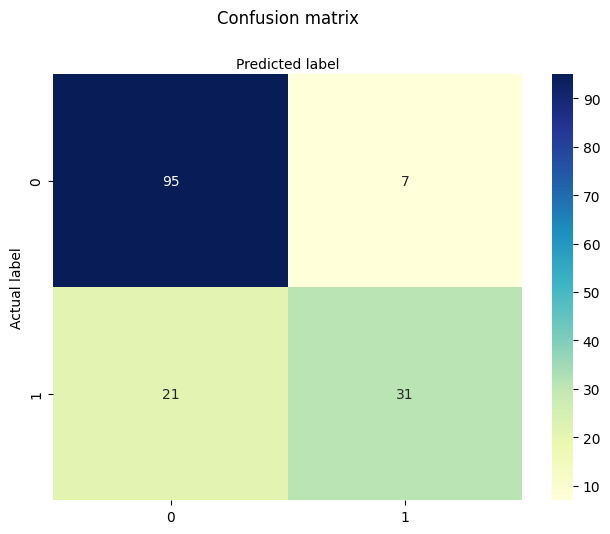

In [8]:
#Visualizing confusion matrix using a heatmap
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#Text(0.5,257.44,'Predicted label');

In [9]:
# Confusion matrix evaluation metrics
# Let's evaluate the model using classification_report for accuracy, precision, and recall.
from sklearn.metrics import classification_report
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.82      0.93      0.87       102
   with diabetes       0.82      0.60      0.69        52

        accuracy                           0.82       154
       macro avg       0.82      0.76      0.78       154
    weighted avg       0.82      0.82      0.81       154



In [10]:
# Well, you got a classification rate of 80%, considered as good accuracy.

# Precision: Precision is about being precise, i.e., how accurate your model is. 
# In your prediction case, when your logistic regression model predicted patients are going to suffer from diabetes, 
# that patients have 73% of the time.

# Recall: If there are patients who have diabetes in the test set and your logistic regression model can identify it 57% of the time.

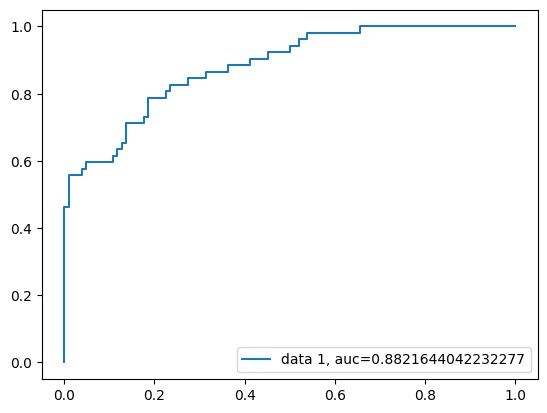

In [11]:
#  ROC curve -Receiver Operating Characteristic (ROC) curve is a plot of the true positive rate against the false positive rate.

# AUC (Area Under the Curve) score for the case is 0.88. AUC score 1 represents a perfect classifier, and 0.5 represents a worthless classifier.
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()